# Experiment 4 — Cloud Style Comparison

**Goal:** Compare ICP performance across five source cloud geometries:
- `random` — uniform blob (near-spherical symmetry → ICP gets stuck in local minima)
- `clustered` — 8 dense Gaussian clusters (distinct spatial anchors)
- `lattice` — 3-D grid with anisotropic axis spacing (structured, axis-distinguishable)
- `2d-lattice` — flat, planar grid variant of `lattice` (near-degenerate depth)
- `muscle-fiber` — nuclei-like points on parallel, hexagonally packed fiber surfaces

For each style we visualise the source cloud and evaluate ICP accuracy over 30 random seeds.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from icp import ICP
from experiment_runner import fit_multi_seed
from synthetic import SyntheticExperiment, CloudStyle
from visualization import PointCloudVisualizer, ErrorMetricsVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

N_SEEDS = 30
SEEDS = list(range(N_SEEDS))
GEN_KWARGS = dict(n=2000, noise_std=3.0, t_scale=8.0)
STYLES = ['random', 'clustered', 'lattice', '2d-lattice', 'muscle-fiber']
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

icp = ICP(max_iter=400, tol=1e-10, verbose=False)

In [2]:
def visualize_cloud(style: CloudStyle, seed: int = 0) -> None:
    """Plot XY, XZ, YZ projections and a 3D view of the source cloud for a given style."""
    exp = SyntheticExperiment.generate(**GEN_KWARGS, seed=seed, style=style)
    fig = plt.figure(figsize=(16, 4))
    axes = [fig.add_subplot(1, 4, i + 1) for i in range(3)]
    PointCloudVisualizer.plot_projections(axes, exp.S)
    ax_3d = fig.add_subplot(1, 4, 4, projection='3d')
    PointCloudVisualizer.plot_scatter_3d(ax_3d, exp.S)
    ax_3d.set_title('3D')
    fig.suptitle(f'Source cloud — style={style!r}  (n={len(exp.S)})')
    plt.tight_layout()
    plt.savefig(f'../results/4_cloud_styles_{style}_cloud.png', dpi=150, bbox_inches='tight')
    plt.show()

## 1. Random

Points drawn uniformly from $[-30, 30]^3$.  The resulting blob has approximate spherical symmetry — any rotation produces a nearly identical cloud, so nearest-neighbour matching provides no rotational signal and ICP gets trapped in local minima.

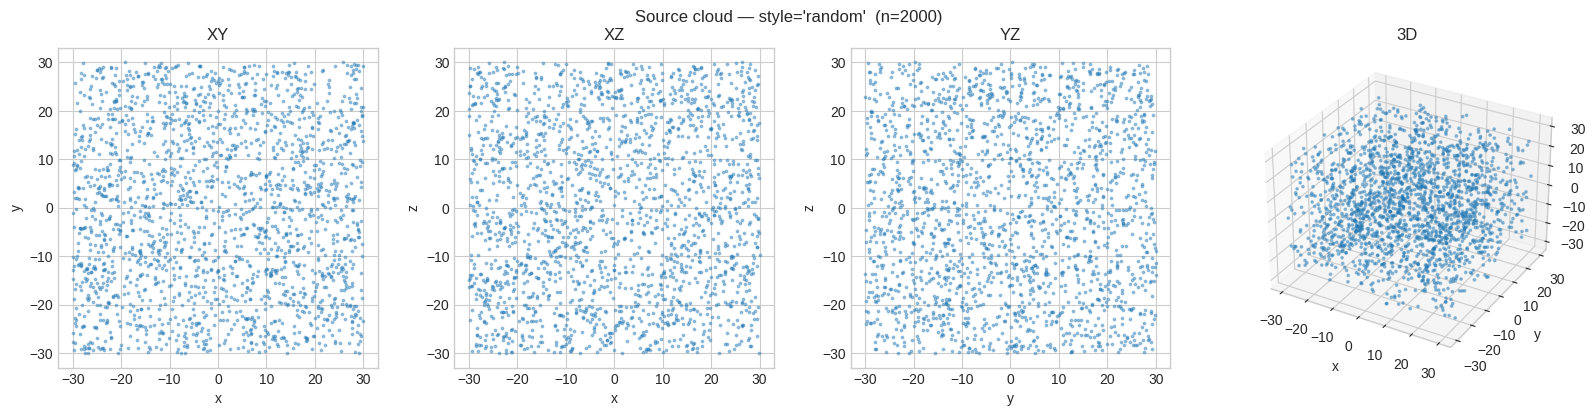

In [3]:
visualize_cloud('random')

Solving 30 seeds: 100%|██████████| 30/30 [00:15<00:00,  1.94it/s]


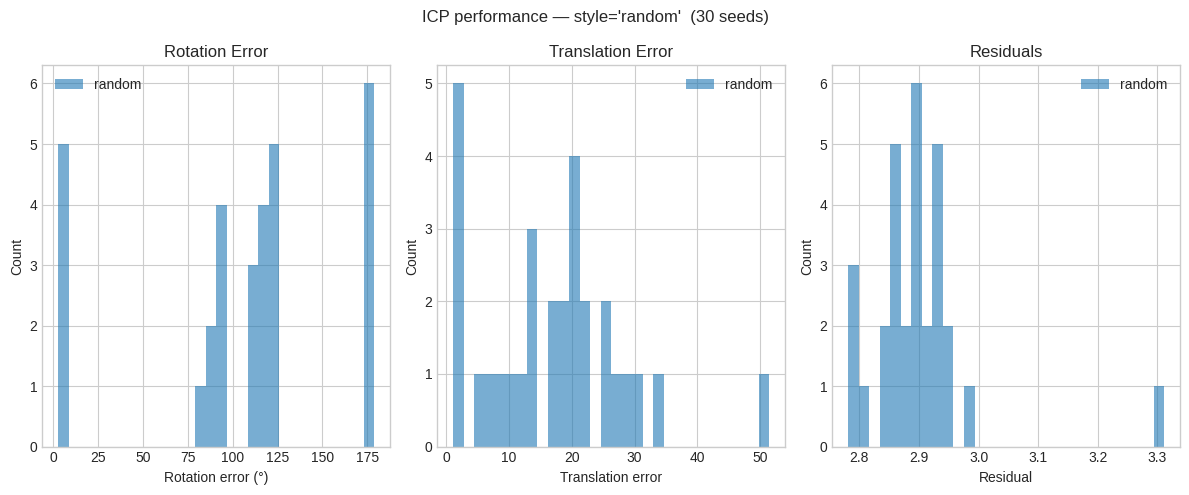

In [4]:
ms_random = fit_multi_seed(icp, SEEDS, experiment_kwargs={**GEN_KWARGS, 'style': 'random'})

fig, axes = ErrorMetricsVisualizer.plot_hists_over_seeds(
    [np.array(ms_random.rotation_errors)],
    [np.array(ms_random.translation_errors)],
    [np.array(ms_random.mean_residuals)],
    method_labels=['random'],
    method_colors=['tab:blue'],
)
fig.suptitle(f"ICP performance — style='random'  ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_random_hists.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Clustered

8 dense Gaussian clusters with centres placed randomly in $[-20, 20]^3$.  Each cluster acts as a distinct spatial anchor: an incorrect rotation that swaps two clusters incurs a large residual, giving ICP a strong signal to correct the alignment.

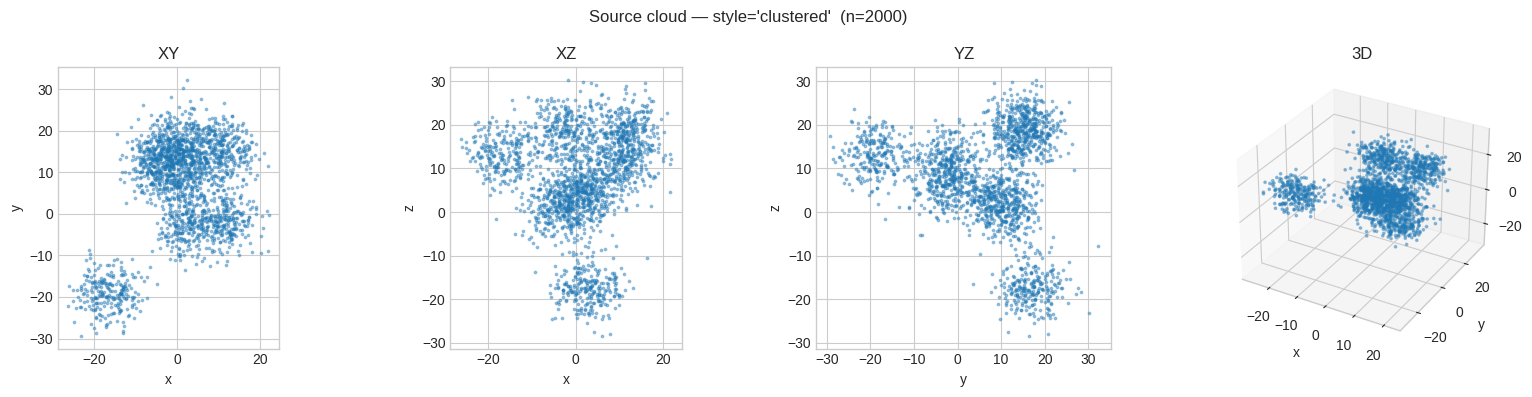

In [5]:
visualize_cloud('clustered')

Solving 30 seeds: 100%|██████████| 30/30 [00:13<00:00,  2.28it/s]


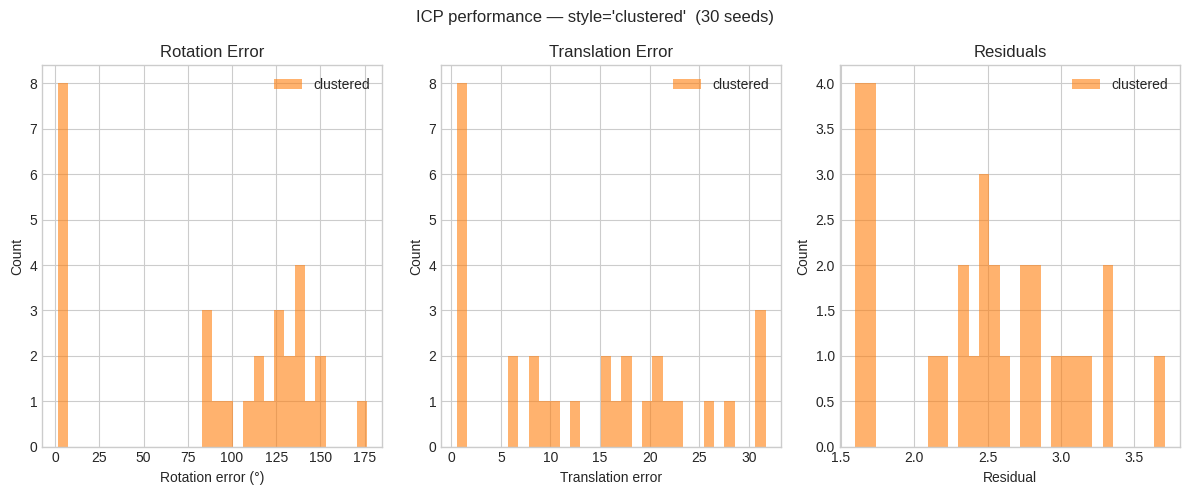

In [6]:
ms_clustered = fit_multi_seed(icp, SEEDS, experiment_kwargs={**GEN_KWARGS, 'style': 'clustered'})

fig, axes = ErrorMetricsVisualizer.plot_hists_over_seeds(
    [np.array(ms_clustered.rotation_errors)],
    [np.array(ms_clustered.translation_errors)],
    [np.array(ms_clustered.mean_residuals)],
    method_labels=['clustered'],
    method_colors=['tab:orange'],
)
fig.suptitle(f"ICP performance — style='clustered'  ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_clustered_hists.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Lattice

3-D regular grid with anisotropic spacing $(2, 3.5, 6)$ along $(x, y, z)$ and slight per-node jitter.  The different spacing per axis makes rotations distinguishable: swapping $x$ and $z$ visibly changes inter-point distances.

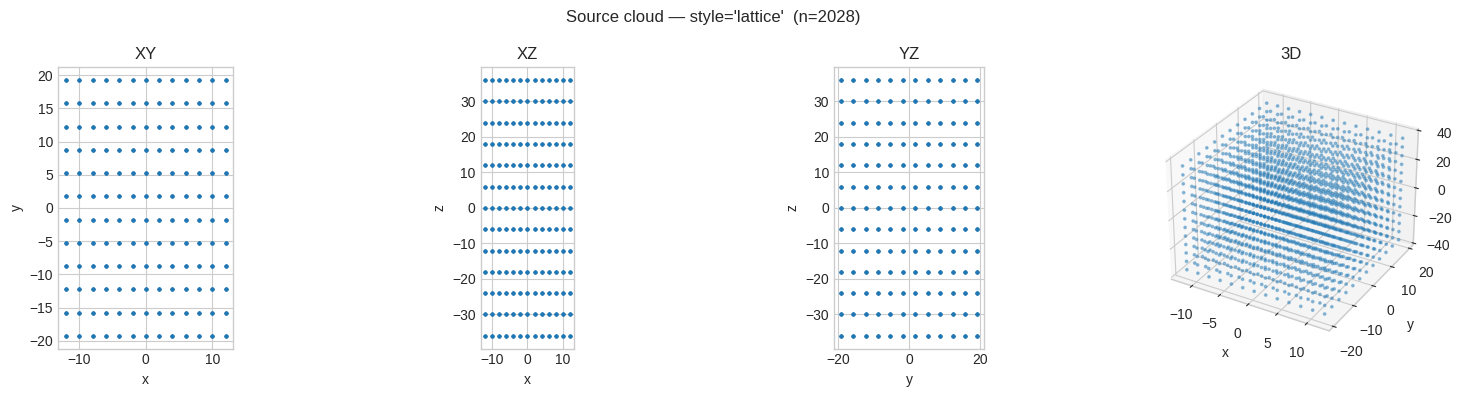

In [7]:
visualize_cloud('lattice')

Solving 30 seeds: 100%|██████████| 30/30 [00:16<00:00,  1.86it/s]


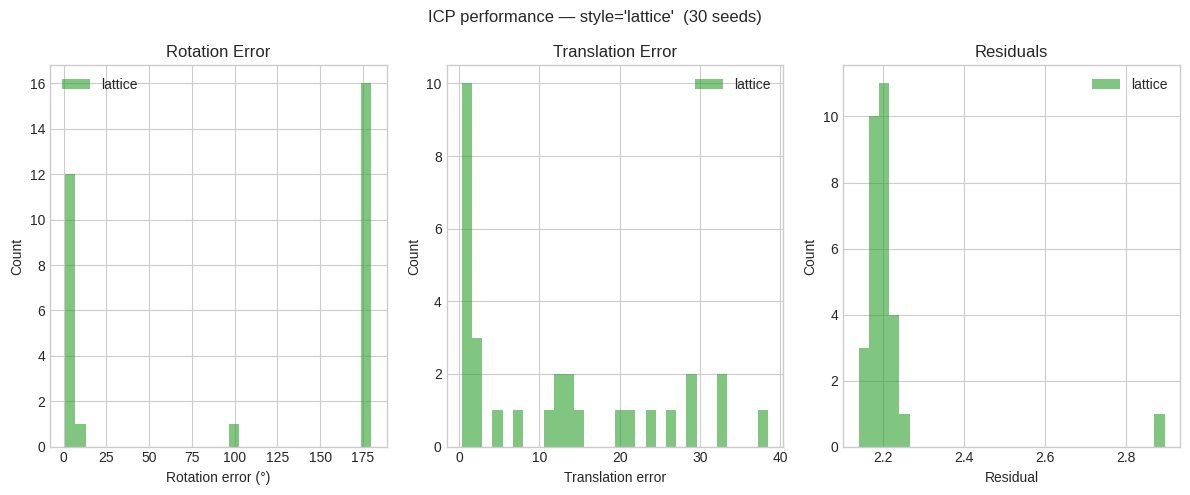

In [8]:
ms_lattice = fit_multi_seed(icp, SEEDS, experiment_kwargs={**GEN_KWARGS, 'style': 'lattice'})

fig, axes = ErrorMetricsVisualizer.plot_hists_over_seeds(
    [np.array(ms_lattice.rotation_errors)],
    [np.array(ms_lattice.translation_errors)],
    [np.array(ms_lattice.mean_residuals)],
    method_labels=['lattice'],
    method_colors=['tab:green'],
)
fig.suptitle(f"ICP performance — style='lattice'  ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_lattice_hists.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 2D Lattice

Flat lattice confined to the XY plane ($z=0$) with anisotropic spacing $(2.0, 3.5)$ and no jitter. Every point has a highly planar local neighbourhood, making this a near-degenerate case: an out-of-plane rotation must be recovered from a cloud that has almost no depth to begin with.

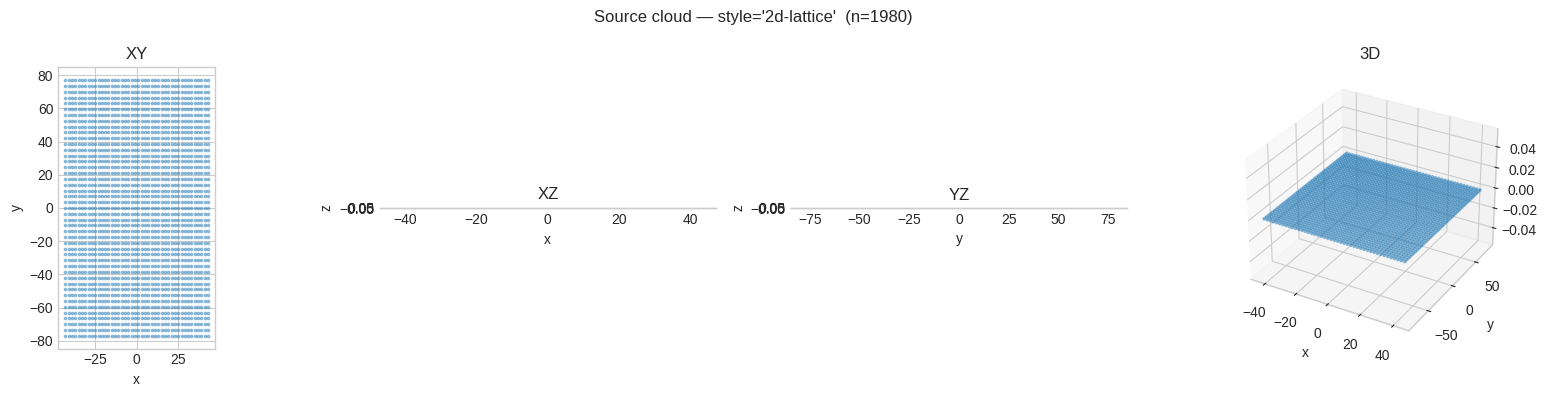

In [9]:
visualize_cloud('2d-lattice')

Solving 30 seeds: 100%|██████████| 30/30 [00:14<00:00,  2.12it/s]


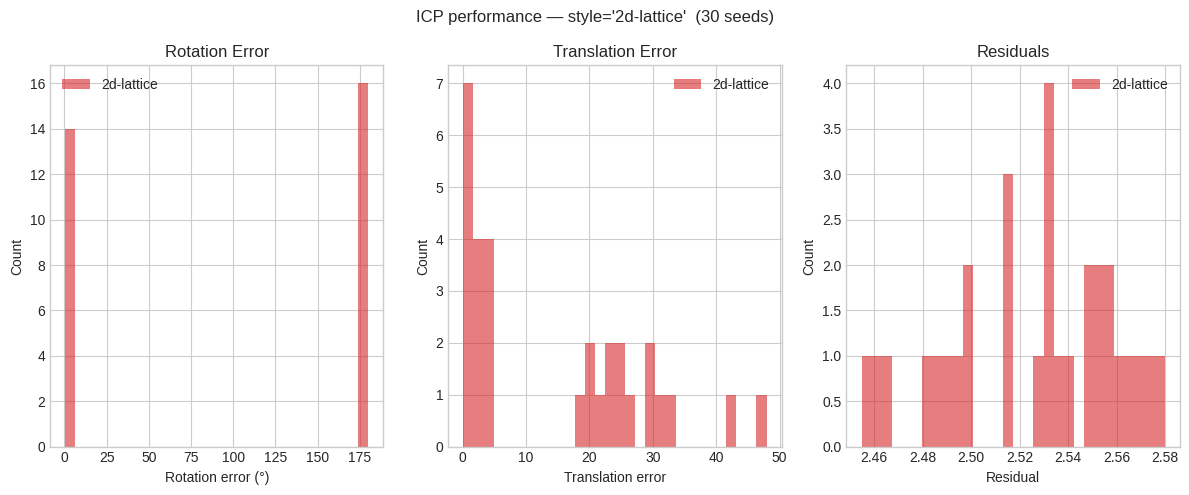

In [10]:
ms_2d_lattice = fit_multi_seed(icp, SEEDS, experiment_kwargs={**GEN_KWARGS, 'style': '2d-lattice'})

fig, axes = ErrorMetricsVisualizer.plot_hists_over_seeds(
    [np.array(ms_2d_lattice.rotation_errors)],
    [np.array(ms_2d_lattice.translation_errors)],
    [np.array(ms_2d_lattice.mean_residuals)],
    method_labels=['2d-lattice'],
    method_colors=['tab:red'],
)
fig.suptitle(f"ICP performance — style='2d-lattice'  ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_2d-lattice_hists.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Muscle Fiber

Nuclei-like points on the periphery of parallel, hexagonally packed fibers (radius $3.0$, spacing $8.0$) — modelling the peripheral nuclear positioning of skeletal muscle fibers. Unlike the other styles, points form many small, separated ring-shaped clusters rather than one continuous blob, giving ICP a very different kind of local structure to exploit.

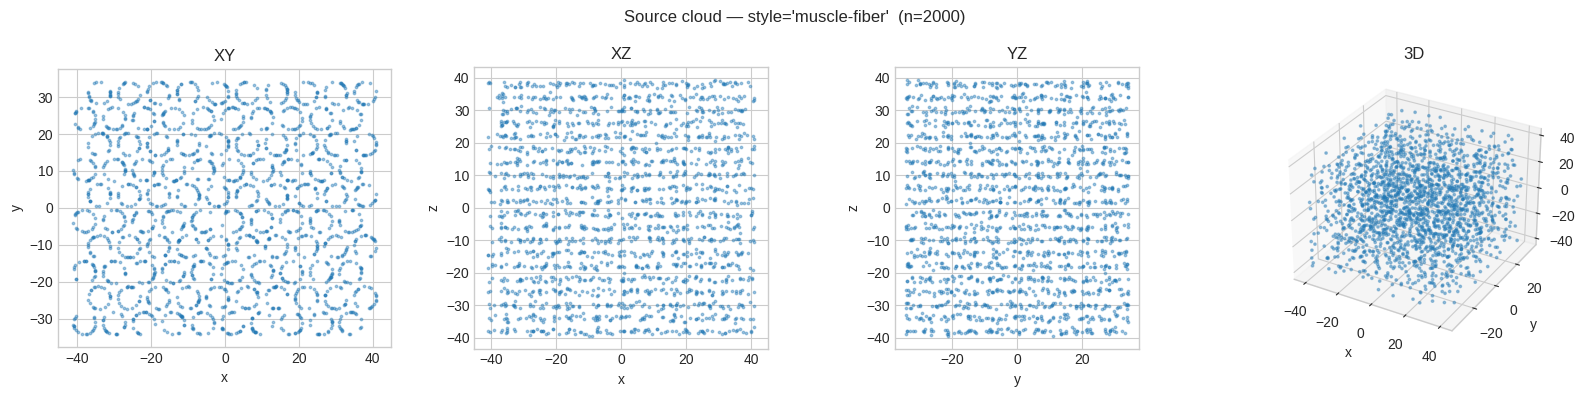

In [11]:
visualize_cloud('muscle-fiber')

Solving 30 seeds: 100%|██████████| 30/30 [00:16<00:00,  1.87it/s]


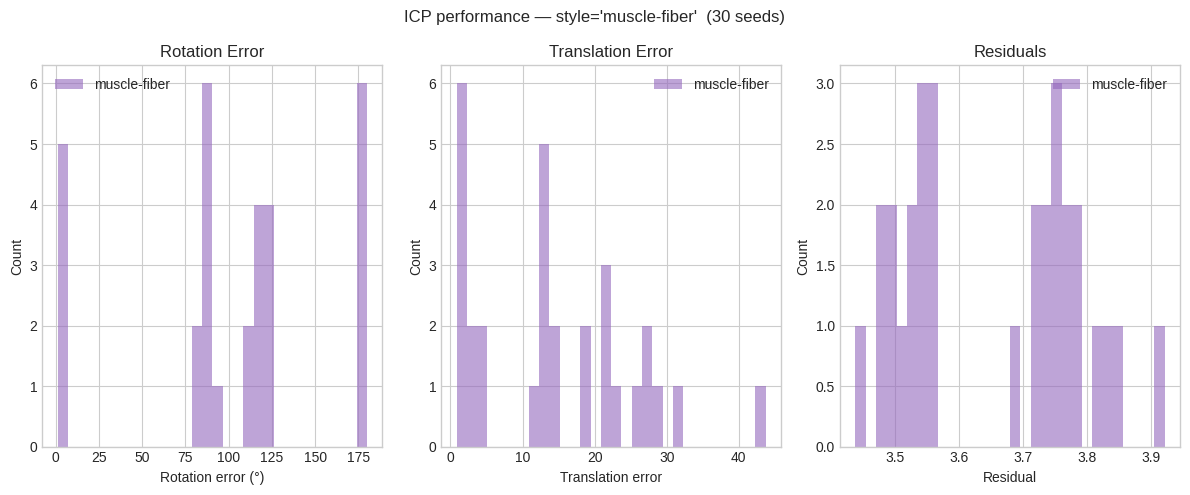

In [12]:
ms_muscle_fiber = fit_multi_seed(icp, SEEDS, experiment_kwargs={**GEN_KWARGS, 'style': 'muscle-fiber'})

fig, axes = ErrorMetricsVisualizer.plot_hists_over_seeds(
    [np.array(ms_muscle_fiber.rotation_errors)],
    [np.array(ms_muscle_fiber.translation_errors)],
    [np.array(ms_muscle_fiber.mean_residuals)],
    method_labels=['muscle-fiber'],
    method_colors=['tab:purple'],
)
fig.suptitle(f"ICP performance — style='muscle-fiber'  ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_muscle-fiber_hists.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Style comparison

All five styles on the same scale.

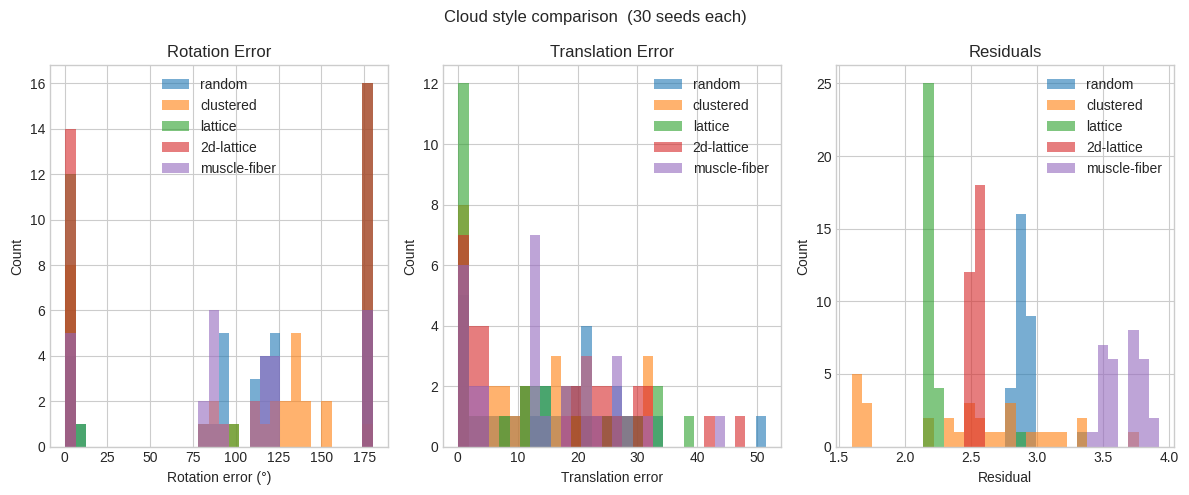

In [13]:
all_ms = {
    'random': ms_random,
    'clustered': ms_clustered,
    'lattice': ms_lattice,
    '2d-lattice': ms_2d_lattice,
    'muscle-fiber': ms_muscle_fiber,
}

fig, axes = ErrorMetricsVisualizer.plot_hists_over_seeds(
    [np.array(all_ms[s].rotation_errors) for s in STYLES],
    [np.array(all_ms[s].translation_errors) for s in STYLES],
    [np.array(all_ms[s].mean_residuals) for s in STYLES],
    method_labels=STYLES,
    method_colors=COLORS,
)
fig.suptitle(f'Cloud style comparison  ({N_SEEDS} seeds each)')
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_comparison.png', dpi=150, bbox_inches='tight')
plt.show()